# Repair Analysis Notebook

This notebook builds:

1. Table 1: Profit pre- vs post-repair
2. Table 2: Repair-only baseline
3. Table 3: Per-constraint repair decomposition
4. Plots for all three analyses

Update `BASE_DIR` to your local folder before running.

In [1]:

import os
import csv
import math
import glob
from dataclasses import dataclass
from typing import List, Tuple, Dict, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Change this path on your laptop
BASE_DIR = ""
PLOT_DIR = os.path.join(BASE_DIR, "repair_analysis_plots_notebook")

FILE_PAIRS = [
    ("gpt4_hourly_arbitrage_Italy.csv", "gpt4_hourly_arbitrage_Italy_corrected3.csv"),
    ("gpt4_hourly_arbitrage_texas_2022.csv", "gpt4_hourly_arbitrage_texas_2022_corrected.csv"),
    ("gpt4_hourly_arbitrage_texas_2023.csv", "gpt4_hourly_arbitrage_texas_2023_corrected.csv"),
    ("gpt4_hourly_arbitrage_new_york_2022.csv", "gpt4_hourly_arbitrage_new_york_2022_corrected_1.csv"),
    ("gpt4_hourly_arbitrage_new_york_2023.csv", "gpt4_hourly_arbitrage_new_york_2023_corrected.csv"),
]

os.makedirs(PLOT_DIR, exist_ok=True)
print("BASE_DIR =", BASE_DIR)
print("PLOT_DIR =", PLOT_DIR)


BASE_DIR = 
PLOT_DIR = repair_analysis_plots_notebook


In [2]:

@dataclass
class BatteryConfig:
    capacity_kwh: float = 43.14
    cmax_kw: float = 10.785
    dmax_kw: float = 10.785
    eta_c: float = 0.95
    eta_d: float = 0.95
    soc_min: float = 0.0
    soc_max: float = 1.0
    soc_target: float = 0.0
    dt: float = 1.0
    allow_export: bool = True


def sf(val, default=0.0):
    try:
        v = float(val)
        return default if (math.isnan(v) or math.isinf(v)) else v
    except (ValueError, TypeError):
        return default


def read_csv_days(path):
    with open(path, newline="") as f:
        rows = list(csv.DictReader(f))
    return [rows[i:i+24] for i in range(0, len(rows), 24) if len(rows[i:i+24]) == 24]


def auto_discover_pairs(base_dir: str) -> List[Tuple[str, str]]:
    all_csvs = {os.path.basename(f) for f in glob.glob(os.path.join(base_dir, "*.csv"))}
    pairs = []
    seen = set()
    for fname in sorted(all_csvs):
        if "_corrected" in fname:
            base = fname.split("_corrected")[0] + ".csv"
            if base in all_csvs and base not in seen:
                pairs.append((base, fname))
                seen.add(base)
    return pairs


def make_label(fname: str) -> str:
    return fname.replace("gpt4_hourly_arbitrage_", "").replace(".csv", "")


def colsum_numeric(df: pd.DataFrame, col: str) -> float:
    return pd.to_numeric(df[col], errors="coerce").fillna(0.0).sum()


In [3]:

def forward_simulate_and_clamp(c, d, batt, soc0):
    T, C = 24, batt.capacity_kwh
    c, d = list(c), list(d)
    soc = [soc0]
    for t in range(T):
        delta = (batt.eta_c * c[t] * batt.dt - d[t] * batt.dt / batt.eta_d) / C
        nxt = soc[t] + delta
        if nxt > batt.soc_max:
            needed = (batt.soc_max - soc[t]) * C + d[t] * batt.dt / batt.eta_d
            c[t] = max(0.0, needed / (batt.eta_c * batt.dt))
            nxt = batt.soc_max
        elif nxt < batt.soc_min:
            available = (soc[t] - batt.soc_min) * C + batt.eta_c * c[t] * batt.dt
            d[t] = max(0.0, available * batt.eta_d / batt.dt)
            nxt = batt.soc_min
        soc.append(nxt)
    return c, d, soc


def minimal_correct(c_orig, d_orig, batt, soc0, forecast_prices, max_iter=3):
    T, C = 24, batt.capacity_kwh
    c = [max(0.0, min(float(x), batt.cmax_kw)) for x in c_orig]
    d = [max(0.0, min(float(x), batt.dmax_kw)) for x in d_orig]

    for t in range(T):
        if c[t] > 1e-6 and d[t] > 1e-6:
            ce = c[t] * batt.eta_c * batt.dt
            de = d[t] * batt.dt / batt.eta_d
            if ce >= de:
                c[t] = (ce - de) / (batt.eta_c * batt.dt)
                d[t] = 0.0
            else:
                c[t] = 0.0
                d[t] = (de - ce) * batt.eta_d / batt.dt

    for _ in range(max_iter):
        c, d, soc = forward_simulate_and_clamp(c, d, batt, soc0)
        if soc[T] >= batt.soc_target - 1e-6:
            break

        deficit_kwh = (batt.soc_target - soc[T]) * C
        for t in sorted(range(T), key=lambda t: forecast_prices[t]):
            if deficit_kwh <= 1e-6:
                break

            headroom_power = batt.cmax_kw - c[t]
            headroom_soc = (
                (batt.soc_max - soc[t]) * C / (batt.eta_c * batt.dt)
                if soc[t] < batt.soc_max else 0.0
            )
            add_p = max(0.0, min(headroom_power, headroom_soc))

            if add_p > 1e-6:
                e_add = min(add_p * batt.eta_c * batt.dt, deficit_kwh)
                c[t] += e_add / (batt.eta_c * batt.dt)
                deficit_kwh -= e_add

            if deficit_kwh > 1e-6 and d[t] > 1e-6:
                e_save = min(d[t] * batt.dt / batt.eta_d, deficit_kwh)
                d[t] = max(0.0, d[t] - e_save * batt.eta_d / batt.dt)
                deficit_kwh -= e_save

    c, d, soc = forward_simulate_and_clamp(c, d, batt, soc0)
    return c, d, soc


def compute_profit_from_cd(c, d, soc, actual_prices, actual_demand, batt):
    total = 0.0
    dt = batt.dt
    for t in range(24):
        net = actual_demand[t] + c[t] - d[t]
        imp_t = max(net, 0.0)
        exp_t = max(-net, 0.0) if batt.allow_export else 0.0
        baseline = actual_prices[t] * actual_demand[t] * dt
        actual_cost = actual_prices[t] * imp_t * dt - actual_prices[t] * exp_t * dt
        total += baseline - actual_cost
    return total


In [4]:

def apply_C4_only(c, d, batt, soc0, _fp):
    c_f = [max(0.0, min(float(x), batt.cmax_kw)) for x in c]
    d_f = [float(x) for x in d]
    return forward_simulate_and_clamp(c_f, d_f, batt, soc0)


def apply_C5_only(c, d, batt, soc0, _fp):
    c_f = [float(x) for x in c]
    d_f = [max(0.0, min(float(x), batt.dmax_kw)) for x in d]
    return forward_simulate_and_clamp(c_f, d_f, batt, soc0)


def apply_C4C5(c, d, batt, soc0, _fp):
    c_f = [max(0.0, min(float(x), batt.cmax_kw)) for x in c]
    d_f = [max(0.0, min(float(x), batt.dmax_kw)) for x in d]
    return forward_simulate_and_clamp(c_f, d_f, batt, soc0)


def apply_C6_only(c, d, batt, soc0, _fp):
    c_f = [float(x) for x in c]
    d_f = [float(x) for x in d]
    for t in range(24):
        if c_f[t] > 1e-6 and d_f[t] > 1e-6:
            ce = c_f[t] * batt.eta_c * batt.dt
            de = d_f[t] * batt.dt / batt.eta_d
            if ce >= de:
                c_f[t] = (ce - de) / (batt.eta_c * batt.dt)
                d_f[t] = 0.0
            else:
                c_f[t] = 0.0
                d_f[t] = (de - ce) * batt.eta_d / batt.dt
    return forward_simulate_and_clamp(c_f, d_f, batt, soc0)


def apply_C1C7C12(c, d, batt, soc0, _fp):
    c_f = [float(x) for x in c]
    d_f = [float(x) for x in d]
    return forward_simulate_and_clamp(c_f, d_f, batt, soc0)


def apply_full(c, d, batt, soc0, fp):
    return minimal_correct(c, d, batt, soc0, fp)


PARTIAL_REPAIRS = {
    "C4 (charge clip)": apply_C4_only,
    "C5 (discharge clip)": apply_C5_only,
    "C4+C5 (power clip)": apply_C4C5,
    "C6 (no simult c/d)": apply_C6_only,
    "C1+C7+C12 (SOC clamp)": apply_C1C7C12,
    # "Full repair": apply_full,
}


In [5]:

def profit_comparison_table(base_dir, file_pairs):
    records = []
    for orig_name, corr_name in file_pairs:
        orig_path = os.path.join(base_dir, orig_name)
        corr_path = os.path.join(base_dir, corr_name)
        if not (os.path.exists(orig_path) and os.path.exists(corr_path)):
            continue

        df_orig = pd.read_csv(orig_path)
        df_corr = pd.read_csv(corr_path)

        orig_profit = colsum_numeric(df_orig, "profit_step")
        corr_profit = colsum_numeric(df_corr, "profit_step")

        records.append({
            "Dataset": make_label(orig_name),
            "Days": len(df_orig) // 24,
            "Pre-Repair Profit": round(orig_profit, 2),
            "Post-Repair Profit": round(corr_profit, 2),
            "Δ Profit": round(corr_profit - orig_profit, 2),
            "Δ %": round((corr_profit - orig_profit) / abs(orig_profit) * 100, 2) if orig_profit != 0 else 0.0,
        })
    return pd.DataFrame(records)


def repair_only_baseline(base_dir, file_pairs, n_sample=None):
    records = []
    batt = BatteryConfig()
    soc0 = 0.5

    for orig_name, corr_name in file_pairs:
        orig_path = os.path.join(base_dir, orig_name)
        corr_path = os.path.join(base_dir, corr_name)
        if not os.path.exists(orig_path):
            continue

        days = read_csv_days(orig_path)
        if n_sample and n_sample < len(days):
            days = days[:n_sample]

        zero_total = 0.0
        gpt_total = 0.0
        repaired_total = 0.0

        for day_rows in days:
            prices_actual = [sf(r["prices_actual"]) for r in day_rows]
            prices_forecast = [sf(r["prices_forecast"]) for r in day_rows]
            actual_demand = [sf(r["actual_demand"]) for r in day_rows]

            gpt_total += sum(sf(r["profit_step"]) for r in day_rows)

            c_zero = [0.0] * 24
            d_zero = [0.0] * 24
            c_rep, d_rep, soc_rep = minimal_correct(c_zero, d_zero, batt, soc0, prices_forecast)
            zero_total += compute_profit_from_cd(c_rep, d_rep, soc_rep, prices_actual, actual_demand, batt)

        if os.path.exists(corr_path):
            df_c = pd.read_csv(corr_path)
            if n_sample:
                df_c = df_c.iloc[:n_sample * 24]
            repaired_total = colsum_numeric(df_c, "profit_step")

        records.append({
            "Dataset": make_label(orig_name),
            "Days": len(days),
            "Zero→Repair Profit": round(zero_total, 2),
            "GPT (pre-repair) Profit": round(gpt_total, 2),
            "GPT+Repair Profit": round(repaired_total, 2) if os.path.exists(corr_path) else "N/A",
            "Repair-only / GPT+Repair": (
                f"{zero_total / repaired_total * 100:.1f}%"
                if os.path.exists(corr_path) and repaired_total != 0 else "N/A"
            ),
        })

    return pd.DataFrame(records)


def per_constraint_decomposition(base_dir, file_pairs):
    batt = BatteryConfig()
    soc0 = 0.5
    records = []

    for orig_name, corr_name in file_pairs:
        orig_path = os.path.join(base_dir, orig_name)
        corr_path = os.path.join(base_dir, corr_name)
        if not os.path.exists(orig_path):
            continue

        days = read_csv_days(orig_path)
        pre_total = sum(sum(sf(r["profit_step"]) for r in d) for d in days)
        post_total = colsum_numeric(pd.read_csv(corr_path), "profit_step") if os.path.exists(corr_path) else np.nan

        label = make_label(orig_name)
        records.append({"Dataset": label, "Repair": "None (original)", "Profit": round(pre_total, 2)})

        for repair_name, repair_fn in PARTIAL_REPAIRS.items():
            total = 0.0
            for day_rows in days:
                pa = [sf(r["prices_actual"]) for r in day_rows]
                pf = [sf(r["prices_forecast"]) for r in day_rows]
                ad = [sf(r["actual_demand"]) for r in day_rows]
                c_o = [sf(r["charge_MW"]) for r in day_rows]
                d_o = [sf(r["discharge_MW"]) for r in day_rows]

                c_f, d_f, s_f = repair_fn(c_o, d_o, batt, soc0, pf)
                total += compute_profit_from_cd(c_f, d_f, s_f, pa, ad, batt)

            records.append({"Dataset": label, "Repair": repair_name, "Profit": round(total, 2)})

        records.append({"Dataset": label, "Repair": "Full Repair", "Profit": round(post_total, 2)})

    return pd.DataFrame(records)


def cumulative_daily_profit(base_dir, file_pairs):
    result = {}
    for orig_name, corr_name in file_pairs:
        orig_path = os.path.join(base_dir, orig_name)
        corr_path = os.path.join(base_dir, corr_name)
        if not (os.path.exists(orig_path) and os.path.exists(corr_path)):
            continue

        days_o = read_csv_days(orig_path)
        days_c = read_csv_days(corr_path)
        n = min(len(days_o), len(days_c))

        daily_o = [sum(sf(r["profit_step"]) for r in d) for d in days_o[:n]]
        daily_c = [sum(sf(r["profit_step"]) for r in d) for d in days_c[:n]]
        result[make_label(orig_name)] = (np.cumsum(daily_o), np.cumsum(daily_c))
    return result


In [6]:
def random_schedule(batt, p_charge=0.35, p_discharge=0.35, seed=None):
    """
    Generate a random infeasible-or-feasible raw battery schedule.

    For each hour:
    - with probability p_charge, assign a random charging power
    - with probability p_discharge, assign a random discharging power
    - both can happen simultaneously on purpose, because repair should fix that

    Returns
    -------
    c_rand : list of length 24
        Raw random charging powers
    d_rand : list of length 24
        Raw random discharging powers
    """
    rng = np.random.default_rng(seed)

    c_rand = []
    d_rand = []

    for _ in range(24):
        # Randomly decide whether to charge/discharge this hour
        do_c = rng.random() < p_charge
        do_d = rng.random() < p_discharge

        # Random power levels, sometimes near max
        c_val = rng.uniform(0.0, batt.cmax_kw) if do_c else 0.0
        d_val = rng.uniform(0.0, batt.dmax_kw) if do_d else 0.0

        c_rand.append(c_val)
        d_rand.append(d_val)

    return c_rand, d_rand

def repair_only_baseline_random(
    base_dir,
    file_pairs,
    n_sample=None,
    n_random_trials=20,
    seed=123,
):
    """
    Random-schedule -> repair baseline.

    For each day:
    1) generate several random raw schedules
    2) repair each one using the same deterministic repair pipeline
    3) compute realized profit using actual prices/demand
    4) average across trials

    This tells us whether the repair pipeline can turn garbage schedules
    into something profitable on its own.

    Parameters
    ----------
    base_dir : str
        Folder containing original and corrected CSV files.
    file_pairs : list of tuples
        [(original_file, corrected_file), ...]
    n_sample : int or None
        If set, use only the first n_sample days from each dataset.
    n_random_trials : int
        Number of random schedules tried per day.
    seed : int
        Base seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        Summary table for the random->repair baseline.
    """
    records = []
    batt = BatteryConfig()
    soc0 = 0.5

    master_rng = np.random.default_rng(seed)

    for orig_name, corr_name in file_pairs:
        orig_path = os.path.join(base_dir, orig_name)
        corr_path = os.path.join(base_dir, corr_name)

        if not os.path.exists(orig_path):
            continue

        days = read_csv_days(orig_path)
        if n_sample and n_sample < len(days):
            days = days[:n_sample]

        random_repair_total = 0.0
        gpt_total = 0.0
        repaired_total = 0.0

        for day_idx, day_rows in enumerate(days):
            prices_actual   = [sf(r["prices_actual"])   for r in day_rows]
            prices_forecast = [sf(r["prices_forecast"]) for r in day_rows]
            actual_demand   = [sf(r["actual_demand"])   for r in day_rows]

            # GPT raw profit from CSV
            gpt_profit = sum(sf(r["profit_step"]) for r in day_rows)
            gpt_total += gpt_profit

            # Average repaired random-schedule profit over multiple trials
            day_random_profits = []

            for trial in range(n_random_trials):
                local_seed = int(master_rng.integers(0, 10**9))
                c_rand, d_rand = random_schedule(batt, seed=local_seed)

                c_rep, d_rep, soc_rep = minimal_correct(
                    c_rand, d_rand, batt, soc0, prices_forecast
                )

                rand_profit = compute_profit_from_cd(
                    c_rep, d_rep, soc_rep,
                    prices_actual, actual_demand, batt
                )
                day_random_profits.append(rand_profit)

            random_repair_total += float(np.mean(day_random_profits))

        # Read corrected GPT+Repair total from corrected CSV if available
        if os.path.exists(corr_path):
            df_c = pd.read_csv(corr_path)
            if n_sample:
                df_c = df_c.iloc[:n_sample * 24]
            repaired_total = colsum_numeric(df_c, "profit_step")

        records.append({
            "Dataset": make_label(orig_name),
            "Days": len(days),
            "Random→Repair Profit": round(random_repair_total, 2),
            "GPT (pre-repair) Profit": round(gpt_total, 2),
            "GPT+Repair Profit": round(repaired_total, 2) if os.path.exists(corr_path) else "N/A",
            "Random→Repair / GPT+Repair": (
                f"{random_repair_total / repaired_total * 100:.1f}%"
                if os.path.exists(corr_path) and repaired_total != 0 else "N/A"
            ),
        })

    return pd.DataFrame(records)

In [7]:

def _money_fmt(ax):
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))


def plot_pre_post_bar(df1, save_dir):
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(df1))
    w = 0.35
    ax.bar(x - w / 2, df1["Pre-Repair Profit"], w, label="Pre-Repair")
    ax.bar(x + w / 2, df1["Post-Repair Profit"], w, label="Post-Repair")
    ax.set_xticks(x)
    ax.set_xticklabels(df1["Dataset"], rotation=15, ha="right")
    ax.set_ylabel("Total Profit")
    ax.set_title("Profit: Pre- vs Post-Repair")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    _money_fmt(ax)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "table1_pre_post_profit.png"), dpi=150)
    plt.show()


def plot_cumulative(cum_data, save_dir):
    if not cum_data:
        return
    n = len(cum_data)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
    for i, (lbl, (co, cc)) in enumerate(cum_data.items()):
        ax = axes[0, i]
        ax.plot(co, label="Pre-Repair", lw=1.3)
        ax.plot(cc, label="Post-Repair", lw=1.3)
        ax.set_title(lbl)
        ax.set_xlabel("Day")
        ax.set_ylabel("Cum. Profit")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        _money_fmt(ax)
    fig.suptitle("Cumulative Profit Over Time", fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "table1_cumulative_profit.png"), dpi=150, bbox_inches="tight")
    plt.show()


def plot_repair_baseline(df2, save_dir):
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(df2))
    w = 0.25
    ax.bar(x - w, df2["Zero→Repair Profit"], w, label="Zero→Repair")
    ax.bar(x, df2["GPT (pre-repair) Profit"], w, label="GPT (raw)")
    ax.bar(x + w, df2["GPT+Repair Profit"].replace("N/A", np.nan).astype(float), w, label="GPT+Repair")
    ax.set_xticks(x)
    ax.set_xticklabels(df2["Dataset"], rotation=15, ha="right")
    ax.set_ylabel("Total Profit")
    ax.set_title("Repair-Only Baseline")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    _money_fmt(ax)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "table2_repair_baseline.png"), dpi=150)
    plt.show()


def plot_per_constraint(df3, save_dir):
    datasets = df3["Dataset"].unique()
    repairs = df3["Repair"].unique()
    n_r = len(repairs)

    fig, ax = plt.subplots(figsize=(max(12, 2 * n_r), 6))
    x = np.arange(len(datasets))
    total_width = 0.8
    w = total_width / n_r

    for j, rep in enumerate(repairs):
        vals = []
        for ds in datasets:
            row = df3[(df3["Dataset"] == ds) & (df3["Repair"] == rep)]
            vals.append(row["Profit"].values[0] if len(row) else 0.0)
        ax.bar(x - total_width / 2 + w / 2 + j * w, vals, w, label=rep)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=15, ha="right")
    ax.set_ylabel("Total Profit")
    ax.set_title("Per-Constraint Repair Decomposition")
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1, 1))
    ax.grid(axis="y", alpha=0.3)
    _money_fmt(ax)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "table3_per_constraint.png"), dpi=150, bbox_inches="tight")
    plt.show()


def plot_constraint_delta(df3, save_dir):
    datasets = df3["Dataset"].unique()
    repairs = [r for r in df3["Repair"].unique() if r != "None (original)"]

    fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5), squeeze=False)
    for i, ds in enumerate(datasets):
        ax = axes[0, i]
        sub = df3[df3["Dataset"] == ds]
        base = sub[sub["Repair"] == "None (original)"]["Profit"].values[0]

        labels, deltas = [], []
        for rep in repairs:
            row = sub[sub["Repair"] == rep]
            if len(row):
                labels.append(rep)
                deltas.append(row["Profit"].values[0] - base)

        ax.barh(range(len(labels)), deltas)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel("Δ Profit vs Original")
        ax.set_title(ds, fontsize=10)
        ax.axvline(0, color="black", lw=0.8)
        ax.grid(axis="x", alpha=0.3)

    fig.suptitle("Profit Change from Each Repair Step (vs Original)", fontsize=12, y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "table3_constraint_delta.png"), dpi=150, bbox_inches="tight")
    plt.show()

def plot_repair_baseline_random(df2, save_dir):
    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(len(df2))
    w = 0.25

    ax.bar(x - w, df2["Random→Repair Profit"], w, label="Random→Repair")
    ax.bar(x, df2["GPT (pre-repair) Profit"], w, label="GPT (raw)")
    ax.bar(
        x + w,
        df2["GPT+Repair Profit"].replace("N/A", np.nan).astype(float),
        w,
        label="GPT+Repair",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(df2["Dataset"], rotation=15, ha="right")
    ax.set_ylabel("Total Profit")
    ax.set_title("Random-Schedule Repair Baseline")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "table2_random_repair_baseline.png"), dpi=150)
    plt.show()


In [8]:

pairs = auto_discover_pairs(BASE_DIR)
if not pairs:
    pairs = [
        (o, c)
        for o, c in FILE_PAIRS
        if os.path.exists(os.path.join(BASE_DIR, o)) and os.path.exists(os.path.join(BASE_DIR, c))
    ]

print(f"Found {len(pairs)} file pairs:")
for o, c in pairs:
    print(" ", o, "->", c)


Found 5 file pairs:
  gpt4_hourly_arbitrage_Italy.csv -> gpt4_hourly_arbitrage_Italy_corrected3.csv
  gpt4_hourly_arbitrage_new_york_2022.csv -> gpt4_hourly_arbitrage_new_york_2022_corrected_1.csv
  gpt4_hourly_arbitrage_new_york_2023.csv -> gpt4_hourly_arbitrage_new_york_2023_corrected.csv
  gpt4_hourly_arbitrage_texas_2022.csv -> gpt4_hourly_arbitrage_texas_2022_corrected.csv
  gpt4_hourly_arbitrage_texas_2023.csv -> gpt4_hourly_arbitrage_texas_2023_corrected.csv


## Table 1

In [9]:

df1 = profit_comparison_table(BASE_DIR, pairs)
df1


,Dataset,Days,Pre-Repair Profit,Post-Repair Profit,Δ Profit,Δ %
0,Italy,364,627354.67,607958.31,-19396.36,-3.09
1,new_york_2022,364,831252.26,806722.64,-24529.62,-2.95
2,new_york_2023,364,312220.06,304382.64,-7837.42,-2.51
3,texas_2022,363,505160.24,468406.58,-36753.66,-7.28
4,texas_2023,314,204928.07,197121.33,-7806.74,-3.81


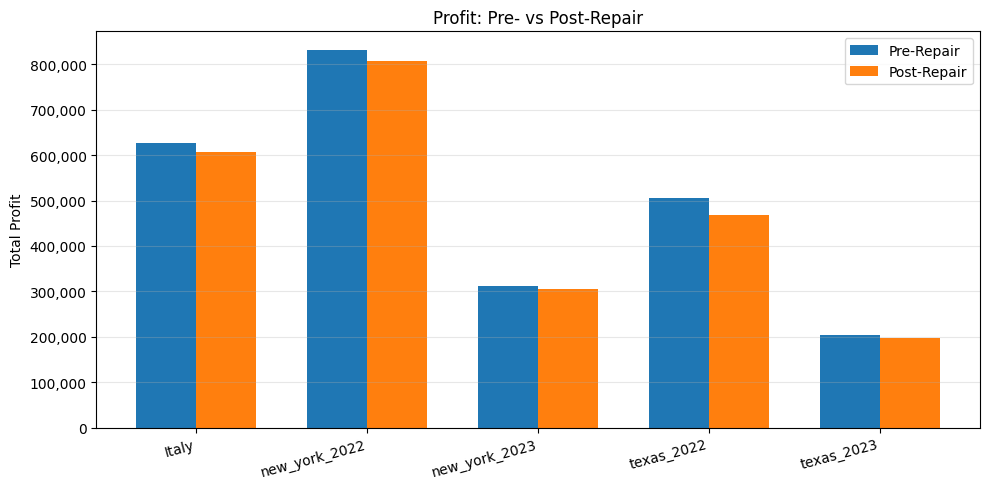

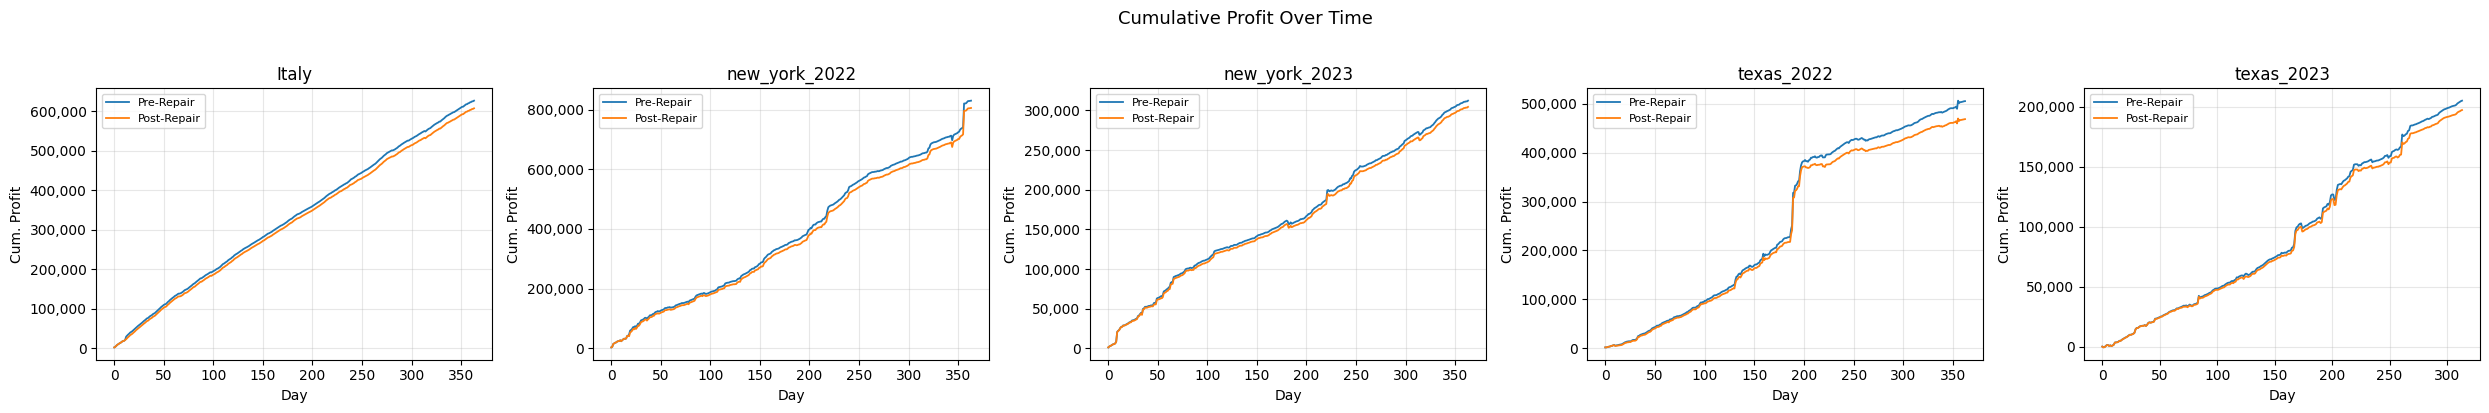

In [10]:

plot_pre_post_bar(df1, PLOT_DIR)
plot_cumulative(cumulative_daily_profit(BASE_DIR, pairs), PLOT_DIR)


## Table 2

In [11]:

df2 = repair_only_baseline(BASE_DIR, pairs)
df2


,Dataset,Days,Zero→Repair Profit,GPT (pre-repair) Profit,GPT+Repair Profit,Repair-only / GPT+Repair
0,Italy,364,0.0,627354.67,607958.31,0.0%
1,new_york_2022,364,0.0,831252.26,806722.64,0.0%
2,new_york_2023,364,0.0,312220.06,304382.64,0.0%
3,texas_2022,363,0.0,505160.24,468406.58,0.0%
4,texas_2023,314,0.0,204928.07,197121.33,0.0%


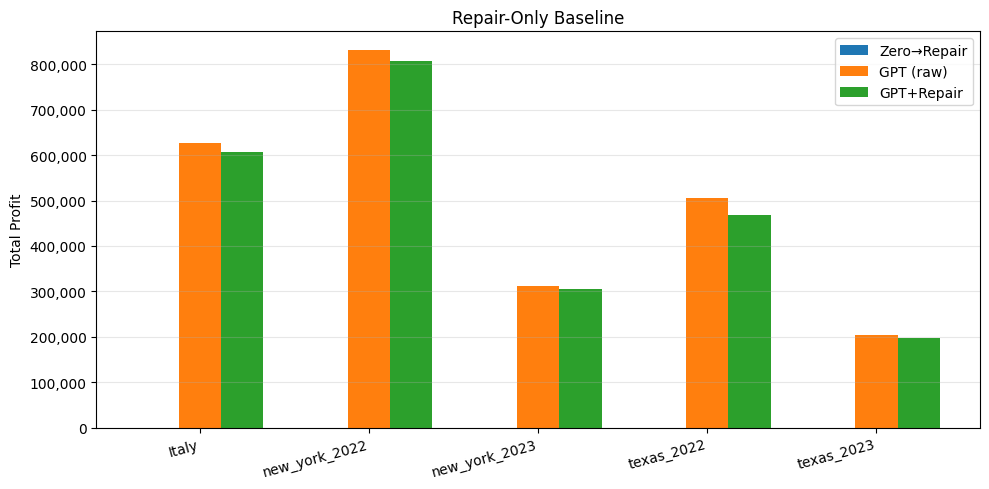

In [12]:

plot_repair_baseline(df2, PLOT_DIR)


In [13]:
df2_random = repair_only_baseline_random(
    BASE_DIR,
    pairs,
    n_random_trials=20,
    seed=123,
)
df2_random

,Dataset,Days,Random→Repair Profit,GPT (pre-repair) Profit,GPT+Repair Profit,Random→Repair / GPT+Repair
0,Italy,364,-22425.27,627354.67,607958.31,-3.7%
1,new_york_2022,364,-29513.61,831252.26,806722.64,-3.7%
2,new_york_2023,364,-7377.34,312220.06,304382.64,-2.4%
3,texas_2022,363,-22545.29,505160.24,468406.58,-4.8%
4,texas_2023,314,-9906.73,204928.07,197121.33,-5.0%


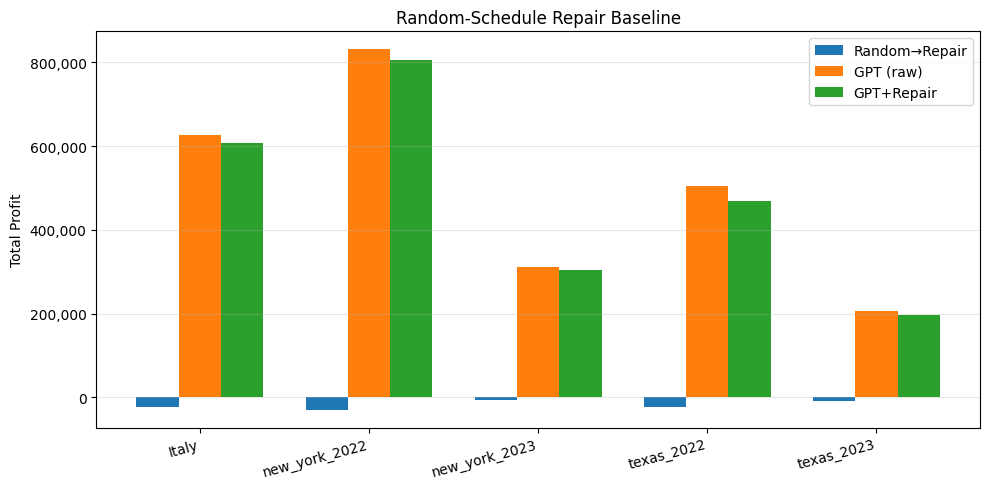

In [14]:
plot_repair_baseline_random(df2_random, PLOT_DIR)

## Table 3

In [15]:

df3 = per_constraint_decomposition(BASE_DIR, pairs)
df3_pivot = df3.pivot(index="Repair", columns="Dataset", values="Profit")
df3_pivot


Dataset,Italy,new_york_2022,new_york_2023,texas_2022,texas_2023
Repair,,,,,
C1+C7+C12 (SOC clamp),562053.08,830444.71,312107.47,504283.97,205150.55
C4 (charge clip),550161.87,826156.79,310226.68,505536.83,205748.78
C4+C5 (power clip),532766.10,798588.25,300763.33,460889.43,195092.77
C5 (discharge clip),533614.30,799171.90,299569.80,452437.75,194377.79
C6 (no simult c/d),562053.08,830444.71,312107.47,504283.97,205150.55
Full Repair,607958.31,806722.64,304382.64,468406.58,197121.33
None (original),627354.67,831252.26,312220.06,505160.24,204928.07


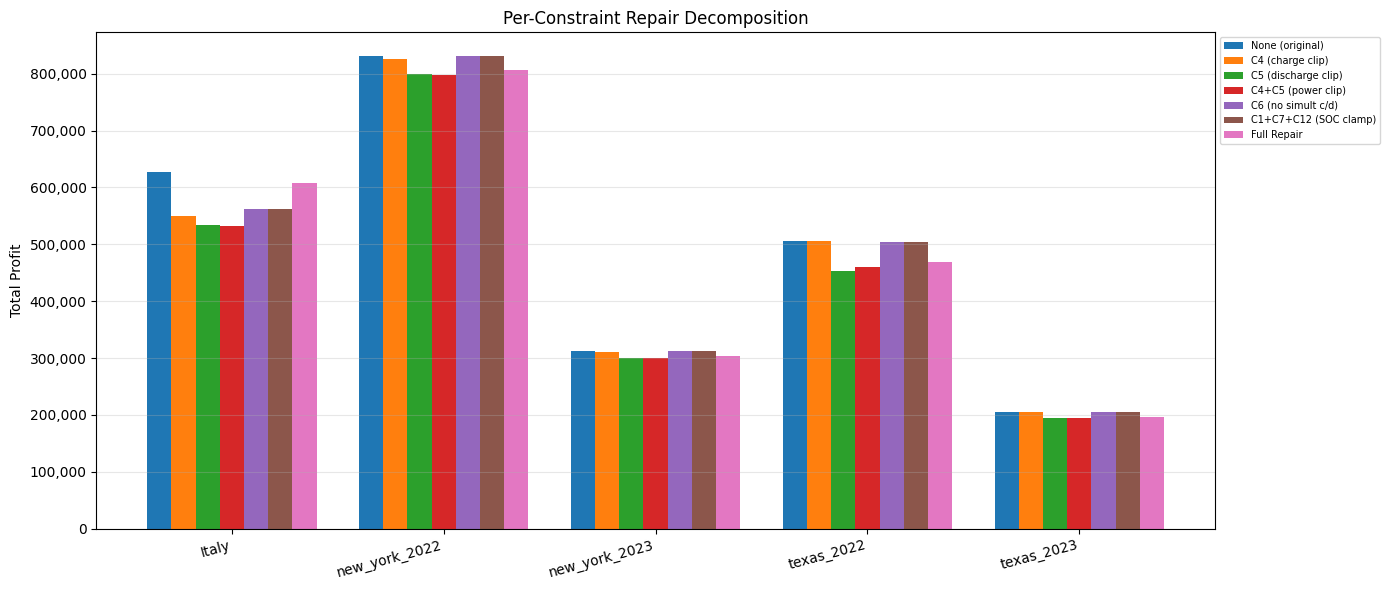

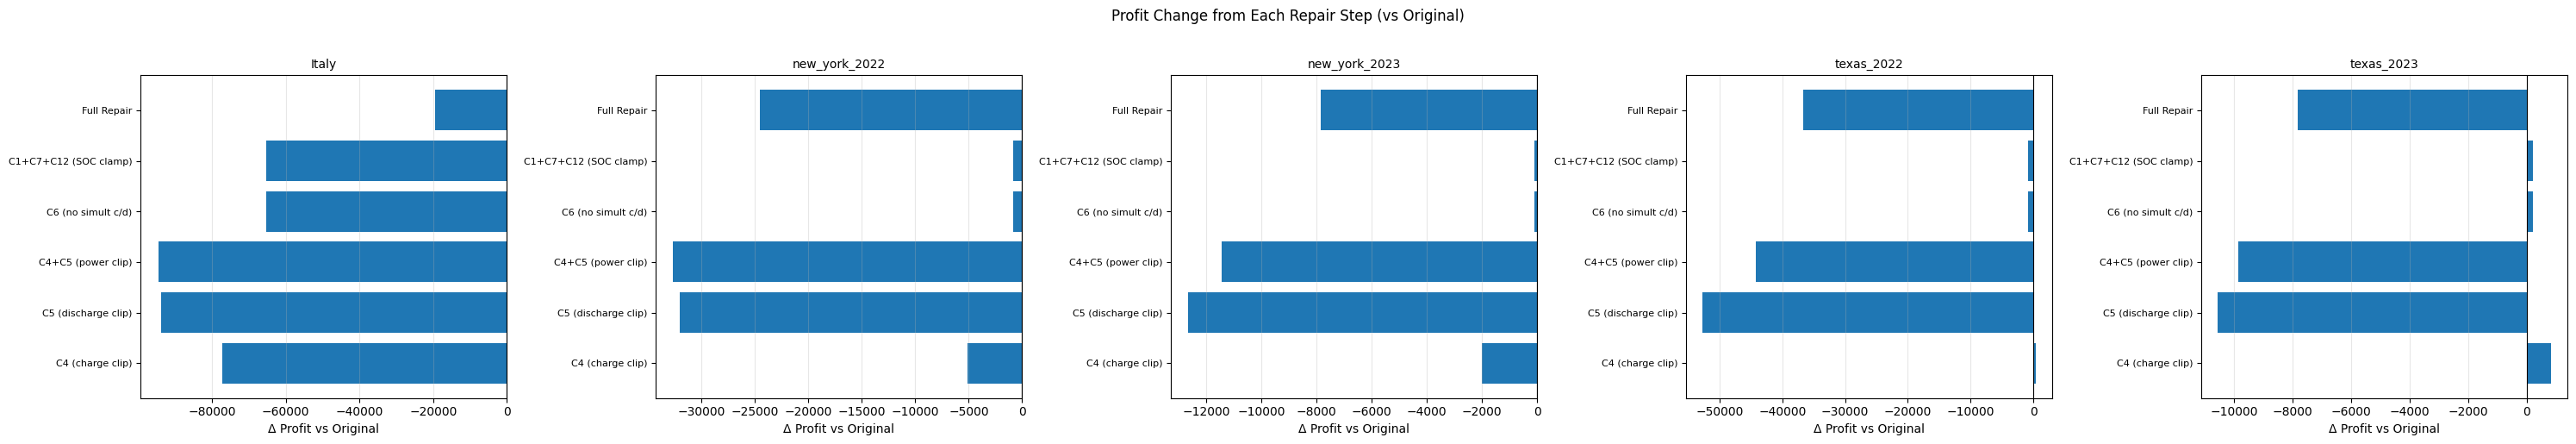

In [16]:

plot_per_constraint(df3, PLOT_DIR)
plot_constraint_delta(df3, PLOT_DIR)


## Save CSV outputs

In [17]:

df1.to_csv(os.path.join(PLOT_DIR, "table1_profit_pre_post.csv"), index=False)
df2.to_csv(os.path.join(PLOT_DIR, "table2_repair_baseline.csv"), index=False)
df2_random.to_csv(
    os.path.join(PLOT_DIR, "table2_random_repair_baseline.csv"),
    index=False
)
df3.to_csv(os.path.join(PLOT_DIR, "table3_per_constraint.csv"), index=False)

print("Saved outputs to:", PLOT_DIR)


Saved outputs to: repair_analysis_plots_notebook
